##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [9]:
# Block 1: Step 1 - Install and Import Libraries
# Installing the required libraries for Lab 4
!pip install -q --upgrade keras-cv
!pip install -q --upgrade keras

import tensorflow as tf
import keras
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("Step 1: Libraries installed and imported successfully.")

Step 1: Libraries installed and imported successfully.


In [10]:
# Block 2: Step 2 - Load the YOLOV8Detector model
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# This is the variable that was missing
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

print("Step 2: Model and resizing layer defined.")

Step 2: Model and resizing layer defined.


In [11]:
# Block 3: Step 3 - Load the images
image_names = ["CAR.jpg", "CAT.jpg", "Chair.jpg", "DOG.jpg", "Person.jpg"]
images = []

for name in image_names:
    img = Image.open(f"/content/{name}").convert("RGB")
    img = img.resize((640, 640))
    images.append(np.array(img))

print(f"Step 3: {len(images)} images loaded.")

Step 3: 5 images loaded.


In [12]:
# Block 4: Step 4 - Predict the classes and bounding boxes
input_images = tf.cast(np.stack(images), dtype=tf.float32)
input_images = inference_resizing(input_images)

predictions = model.predict(input_images)
print("Step 4: Prediction completed.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
Step 4: Prediction completed.


Image      | Object          | Conf      
----------------------------------------
Image 1    | car             | 0.98
Image 2    | tvmonitor       | -1.00
Image 3    | chair           | 1.00
Image 4    | sofa            | 0.90
Image 5    | person          | 0.83


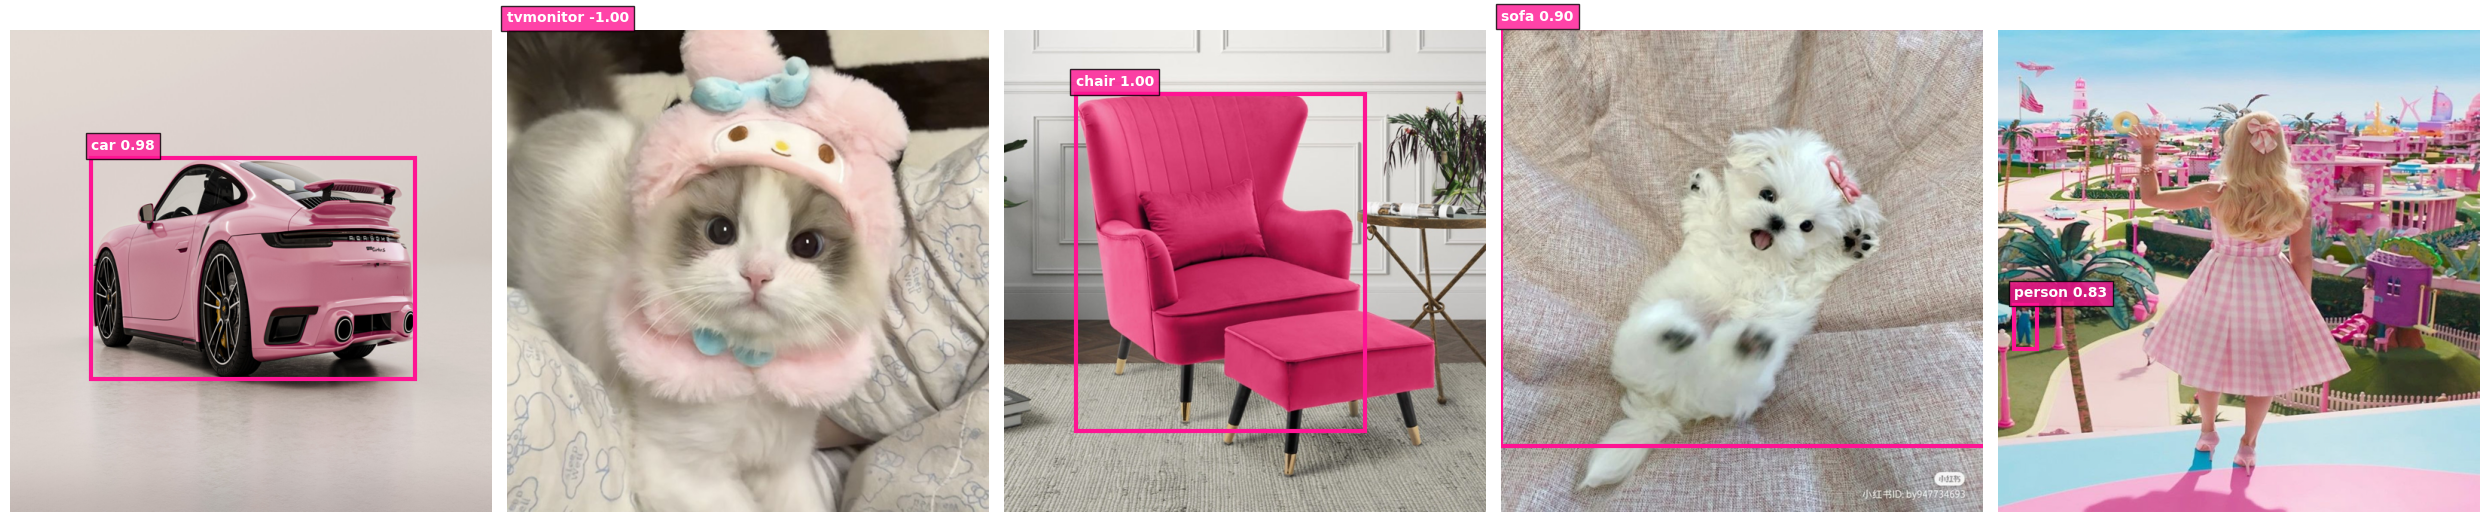

In [13]:
# Block 5: Step 5 - Show the results
class_names = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

plt.figure(figsize=(25, 10))
print(f"{'Image':<10} | {'Object':<15} | {'Conf':<10}")
print("-" * 40)

for i in range(len(images)):
    boxes = predictions['boxes'][i]
    confidence = predictions['confidence'][i]
    classes = predictions['classes'][i]

    label = class_names[int(classes[0])]
    print(f"Image {i+1:<4} | {label:<15} | {confidence[0]:.2f}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(input_images[i].numpy().astype("uint8"))
    ax = plt.gca()

    x, y, w, h = boxes[0]
    rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='deeppink', facecolor='none')
    ax.add_patch(rect)
    plt.text(x, y-10, f"{label} {confidence[0]:.2f}",
             color='white', weight='bold', bbox=dict(facecolor='deeppink', alpha=0.8))
    plt.axis('off')

plt.tight_layout()
plt.show()